# Amazon Sentiment Analysis: Review Polarity Classifier

**OBJECTIVE**
This project focuses on building a Natural Language Processing (NLP) pipeline to classify Amazon customer reviews. Using a dataset of millions of reviews, the goal is to develop a model that can accurately distinguish between Positive and Negative sentiment based purely on the text content.

## Below are the steps or workflow of NPL:

### STEP 1: Install NLP Library

We use the **Natural Language Toolkit (NLTK)**, a leading platform for building Python programs to work with human language data.

```bash
pip install nltk

```

### STEP 2: Import Libraries

In [18]:
!pip install nltk

In [19]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

### STEP 3: Download NLP Resources

We will use **VADER** (**V**alence **A**ware **D**ictionary and s**E**ntiment **R**easoner). It is a "lexicon" (a vocabulary) where words are pre-scored for emotion.

In [20]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### STEP 4: Create Sentiment Analyzer

In [21]:
sia = SentimentIntensityAnalyzer()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

---

# 5. Load the Dataset

The Amazon reviews polarity dataset is constructed by taking review score 1 and 2 as negative, and 4 and 5 as positive. Samples of score 3 is ignored. In the dataset, class 1 is the negative and class 2 is the positive. Each class has 1,800,000 training samples and 200,000 testing samples.

If you need help extracting the train.csv and test.csv files check out the starter code.

The files train.csv and test.csv contain all the training samples as comma-separated values.

The CSVs contain polarity, title, text. These 3 columns in them, correspond to class index (1 or 2), review title and review text.

* polarity - 1 for negative and 2 for positive
* title - review heading
* text - review body

The review title and text are escaped using double quotes ("), and any internal double quote is escaped by 2 double quotes (""). New lines are escaped by a backslash followed with an "n" character, that is "\n".

*Each review is labeled as either:

- 2 (positive)
- 1 (negative)

This makes it a binary classification problem. Since the dataset is zipped, we will read it directly from the ZIP file.

In [24]:
import tarfile
import os

# 1. Path to your downloaded file
zip_path = "/content/drive/MyDrive/amazon_review_polarity_csv.tgz.zip"
extract_path = "/content/amazon_data/"

# 2. Unzip the main .zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 3. Now untar the .tgz file that was inside the zip
# (Adjust the filename if it's slightly different after unzipping)
tgz_file = extract_path + "amazon_review_polarity_csv.tgz"
with tarfile.open(tgz_file, "r:gz") as tar:
    tar.extractall(path=extract_path)

# 4. Load the training or test CSV
# Usually, this dataset extracts into a folder named 'amazon_review_polarity_csv'
df = pd.read_csv(f"{extract_path}amazon_review_polarity_csv/train.csv", header=None, names=['label', 'title', 'content'])

df.head()

/tmp/ipykernel_182/1991484791.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


,label,title,content
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


---

# 6. Inspect the Dataset

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   label    int64 
 1   title    object
 2   content  object
dtypes: int64(1), object(2)
memory usage: 82.4+ MB


In [26]:
df.shape

(3600000, 3)

In [27]:
df.columns

Index(['label', 'title', 'content'], dtype='object')

**Interpretation:**
The dataset has 3,600,000 rows. It has 3 columns: `label`,  `title `and `content`. This means each row contains:

1. the sentiment label
2. a review title (text)
3. content: the product review text

---

# 7. Check Class Balance

In [29]:
df["label"].value_counts()

,count
label,
2,1800000
1,1800000


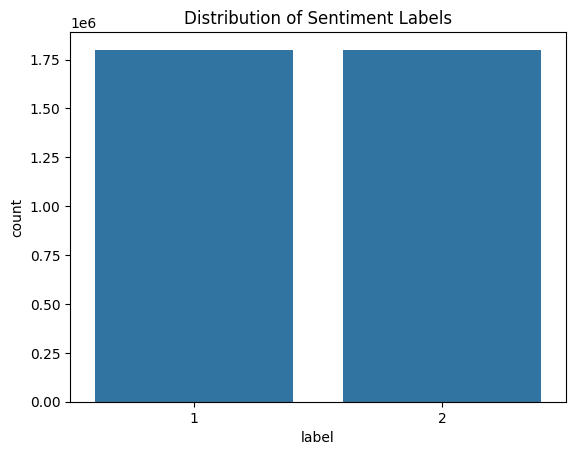

In [30]:
sns.countplot(x="label", data=df)
plt.title("Distribution of Sentiment Labels")
plt.show()

**Interpretation:**
The dataset is balanced, meaning it contains the same number of positive and negative reviews. This is good for training a machine learning model because it prevents the model from favoring one class over the other.

---

# 8. Explore Example Reviews

In [36]:
print("Sample Positive Review:\n")
print(df[df["label"] == 2]["content"].iloc[0])

Sample Positive Review:

This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


In [37]:
print("Sample Negative Review:\n")
print(df[df["label"] == 1]["content"].iloc[0])

Sample Negative Review:

This is a self-published book, and if you want to know why--read a few paragraphs! Those 5 star reviews must have been written by Ms. Haddon's family and friends--or perhaps, by herself! I can't imagine anyone reading the whole thing--I spent an evening with the book and a friend and we were in hysterics reading bits and pieces of it to one another. It is most definitely bad enough to be entered into some kind of a "worst book" contest. I can't believe Amazon even sells this kind of thing. Maybe I can offer them my 8th grade term paper on "To Kill a Mockingbird"--a book I am quite sure Ms. Haddon never heard of. Anyway, unless you are in a mood to send a book to someone as a joke---stay far, far away from this one!


This step helps show that the dataset contains real human language, not short synthetic examples.

---

# 9. Text Analytics: Review Length

Before training a model, it is useful to explore the text. One simple form of text analytics is measuring review length. We can calculate:

* number of characters
* number of words

In [38]:
df["content_length_chars"] = df["content"].apply(len)
df["content_length_words"] = df["content"].apply(lambda x: len(x.split()))
df.head()

,label,title,content,content_length_chars,content_length_words
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...,394,75
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...,470,91
2,2,Amazing!,This soundtrack is my favorite music of all ti...,750,128
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...,721,116
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine...",425,77


In [39]:
df[["content_length_chars", "content_length_words"]].describe()

,content_length_chars,content_length_words
count,3.600000e+06,3.600000e+06
mean,4.051396e+02,7.416885e+01
std,2.342711e+02,4.229870e+01
min,4.000000e+00,1.000000e+00
25%,2.070000e+02,3.900000e+01
50%,3.560000e+02,6.600000e+01
75%,5.660000e+02,1.030000e+02
max,1.010000e+03,2.540000e+02


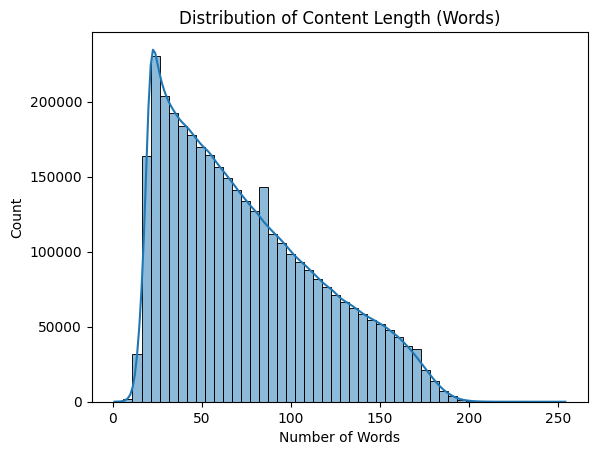

In [40]:
sns.histplot(df["content_length_words"], bins=50, kde=True)
plt.title("Distribution of Content Length (Words)")
plt.xlabel("Number of Words")
plt.show()

**Interpretation:**
This tells us how long the reviews are on average. Some reviews are short, while others are long and detailed. This is part of text analytics — extracting useful patterns from text data.

---

# 10. Why Text Must Be Preprocessed

Computers do not understand language the way humans do. For example, the sentence:

> "This movie was AMAZING!!!"

contains:

* uppercase letters
* punctuation
* emphasis

A machine learning model does not automatically know what these symbols mean. So we preprocess text to make it cleaner and more consistent. Common text preprocessing steps include:

* converting text to lowercase
* removing punctuation
* removing extra spaces
* optionally removing stopwords
* tokenization

---

# 11. Define a Text Cleaning Function

In [41]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

---

# 12. Apply Text Cleaning

In [42]:
df["clean_content"] = df["content"].apply(clean_text)
df[["content", "clean_content"]].head()

,content,clean_content
0,This sound track was beautiful! It paints the ...,this sound track was beautiful it paints the s...
1,I'm reading a lot of reviews saying that this ...,im reading a lot of reviews saying that this i...
2,This soundtrack is my favorite music of all ti...,this soundtrack is my favorite music of all ti...
3,I truly like this soundtrack and I enjoy video...,i truly like this soundtrack and i enjoy video...
4,"If you've played the game, you know how divine...",if youve played the game you know how divine t...


---

# 13. Compare Before and After Cleaning

In [43]:
print("Original Content:\n")
print(df["content"].iloc[0])

print("\n\nCleaned Content:\n")
print(df["clean_content"].iloc[0])

Original Content:

This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


Cleaned Content:

this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cross but out of all of the games i have ever played it has the best music it backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras it would impress anyone who cares to listen


Now the text is in a cleaner format that is easier for the model to process.

---

# 14. Target Labels

Machine learning models can only work directly with numeric labels such as:

* 2 (positive)
* 1 (negative)

So luckily the dataset target labels are numeric.



---

# 15. Define Features and Target

In [44]:
X = df["clean_content"]
y = df["label"]

* `X` contains the input text
* `y` contains the labels which are sentiment

---

# 16. Split the Dataset

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 2880000
Testing set size: 720000


We use 80% of the data for training and 20% of the data for testing. This allows us to measure how well the model performs on unseen data.

---

# 17. Convert Text into Numerical Features with TF-IDF

Machine learning models require numbers, not words. One of the most common NLP techniques for converting text into numbers is called TF-IDF.

**What is TF-IDF?**
TF-IDF stands for:

* **Term Frequency** → how often a word appears in a document
* **Inverse Document Frequency** → how unique or informative that word is across all documents

TF-IDF gives higher importance to words that are frequent in one review but not too common in all reviews.

In [47]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

In [48]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [49]:
X_train_tfidf.shape

(2880000, 5000)

**Interpretation:**
The text has now been transformed into a numerical matrix. Each review is represented by a row of numbers. This is what allows machine learning to work with language.

---

# 18. Train a Sentiment Classification Model

We will use Logistic Regression, a simple but powerful model for binary classification.

In [50]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

The model now learns which patterns in text are associated with positive and negative reviews.

---

# 19. Make Predictions

In [51]:
y_pred = model.predict(X_test_tfidf)

---

# 20. Evaluate the Model

In [52]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8616263888888889


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.86      0.86      0.86    359759
           2       0.86      0.87      0.86    360241

    accuracy                           0.86    720000
   macro avg       0.86      0.86      0.86    720000
weighted avg       0.86      0.86      0.86    720000



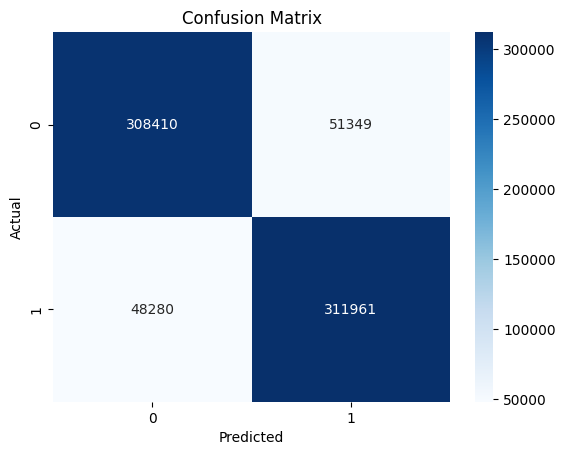

In [54]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Interpreting Accuracy**
* Accuracy tells us the proportion of reviews the model classified correctly. For example: 0.86 means 86% of test reviews were classified correctly.
* All the metrics are 86% for the different sentiment labels, this shows that the dataset was well balanced and the model was able to predict positive and negative sentimental reviews equally.

**Interpreting the Confusion Matrix**
The confusion matrix shows True Positives, True Negatives, False Positives, and False Negatives. This helps us understand where the model is making mistakes.

---

# 21. Build a Prediction Function for New Reviews

In [56]:
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 2:
        return "Positive"
    else:
        return "Negative"

---

# 22. Test the Model on New Reviews

In [57]:
test_review_1 = "The book I purchased had a beauticful cover but as for the content give me zero my girl, she should consider being a book cover maker not an author...."
print(predict_sentiment(test_review_1))

Negative


In [58]:
test_review_2 = "Clothes quality was out of this world, my money's worth...my goodness."
print(predict_sentiment(test_review_2))

Negative


In [59]:
test_review_3 = "Wonderful jewel box---my daughter loved it and it literally stored all her jewelery nicely. She wont lose them ever again or misplace them"
print(predict_sentiment(test_review_3))

Positive


The ouput for the test reviews were predicted as expected.

---

# 23. Practice Section

Try your own review below and see what the model predicts.

In [60]:
my_review = input("Enter your Amazon product review: ")
print("Predicted Sentiment:", predict_sentiment(my_review))

Enter your Amazon product review: I could literally live in this sweater
Predicted Sentiment: Negative


#Conclusion

In this exercise, we used Natural Language Processing to analyze Amazon product review text and classify sentiment. We worked with a real-world dataset, cleaned the text, trained a Logistic Regression classifier, evaluated the model, and predicted sentiment on new reviews.

This project demonstrates how computers can learn patterns in human language and use those patterns to make intelligent predictions.

---

